# Co-Attention Fusion + EDL

Multimodal Sentiment Analysis on MVSA-Single Dataset with Evidential Deep Learning (EDL)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from transformers import RobertaTokenizer, RobertaModel

from PIL import Image
import pandas as pd
import numpy as np
import os
import warnings
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("\u2705 Imports loaded & seed set.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded & seed set.
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # =========================
    # HYPERPARAMETERS
    # =========================
    BATCH_SIZE = 16
    EPOCHS = 30
    LR = 2e-5
    WEIGHT_DECAY = 1e-4
    MAX_LEN = 150
    D_BERT = 768
    D_CNN = 1024
    D_PROJ = 512
    NUM_CLASSES = 3
    ANNEALING_EPOCHS = 10  # KL reaches full strength at epoch 10 (1/3 of training)
    SEED = 42
    DROPOUT = 0.3

    # =========================
    # PRETRAINED MODELS
    # =========================
    TEXT_MODEL = "roberta-base"
    IMAGE_MODEL = "densenet121"

print(f"\u2705 Configuration loaded. Device: {CFG.DEVICE}")


✅ Configuration loaded. Device: cuda


In [3]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df.columns = ["id", "text_label", "image_label", "final_label"]

def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

df = df[df.apply(is_valid, axis=1)]
df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

# Track failed samples for debugging
failed_samples = []

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

if empty_text_count > 0:
    print("IDs with empty text:")
    empty_ids = df[df["text"] == ""]["id"].tolist()
    for idx in empty_ids[:10]:  # Show first 10
        print(f"  - {idx}")
    if len(empty_ids) > 10:
        print(f"  ... and {len(empty_ids) - 10} more")
    print()

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()


Dataset size after filtering: 4511

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [4]:
# ============================================================
# PYTORCH DATASET & DATALOADERS
# ============================================================

# MVSADataset: PyTorch Dataset for MVSA multimodal sentiment analysis.
class MVSADataset(Dataset):

    def __init__(self, dataframe, tokenizer, transform, max_len=150):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) else ""
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load and transform image
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, 224, 224)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }


# ============================================================
# INITIALIZE TOKENIZER & TRANSFORMS
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained(CFG.TEXT_MODEL)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STRATIFIED SPLIT: 70% train, 15% val, 15% test
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=CFG.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=CFG.SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nVal label distribution:")
print(val_df['label'].value_counts().sort_index())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())

# Create datasets
train_dataset = MVSADataset(train_df, tokenizer, image_transform, CFG.MAX_LEN)
val_dataset = MVSADataset(val_df, tokenizer, image_transform, CFG.MAX_LEN)
test_dataset = MVSADataset(test_df, tokenizer, image_transform, CFG.MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\n\u2705 DataLoaders created.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train: 3157 | Val: 677 | Test: 677

Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64

Val label distribution:
label
0    204
1     71
2    402
Name: count, dtype: int64

Test label distribution:
label
0    204
1     70
2    403
Name: count, dtype: int64

✅ DataLoaders created.
Train batches: 198 | Val batches: 43 | Test batches: 43


In [5]:
# ============================================================
# FEATURE EXTRACTORS (Sequence-Level for Attention)
# ============================================================

# RoBERTa text encoder returning sequence-level features.
# Input:  input_ids [B, L_t], attention_mask [B, L_t]
# Output: sequence [B, L_t, d_proj], attention_mask [B, L_t]
class TextEncoder(nn.Module):

    def __init__(self, d_proj=512):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(CFG.TEXT_MODEL)
        # Freeze RoBERTa parameters
        for param in self.roberta.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(CFG.D_BERT, d_proj),
            nn.ReLU()
        )
        self.layer_norm = nn.LayerNorm(d_proj)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # [B, L_t, 768]
        projected = self.layer_norm(self.projection(sequence_output))  # [B, L_t, d_proj]
        return projected, attention_mask


# DenseNet-121 image encoder returning spatial features.
# Input:  image [B, 3, 224, 224]
# Output: spatial [B, H*W, d_proj]
class ImageEncoder(nn.Module):

    def __init__(self, d_proj=512):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.features = densenet.features
        # Freeze DenseNet parameters
        for param in self.features.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(CFG.D_CNN, d_proj),
            nn.ReLU()
        )
        self.layer_norm = nn.LayerNorm(d_proj)

    def forward(self, x):
        with torch.no_grad():
            features = self.features(x)  # [B, 1024, H, W]
        B, C, H, W = features.shape
        
        # Spatial features: reshape to [B, H*W, C] then project
        spatial = features.view(B, C, H * W).permute(0, 2, 1)  # [B, H*W, 1024]
        spatial = self.layer_norm(self.projection(spatial))  # [B, H*W, d_proj]
        
        return spatial


print("\u2705 TextEncoder (sequence) & ImageEncoder (spatial) defined.")


✅ TextEncoder (sequence) & ImageEncoder (spatial) defined.


In [6]:
# ============================================================
# EVIDENTIAL DEEP LEARNING LOSS FUNCTION
# ============================================================

# EDL Loss: Evidential Cross-Entropy + KL Divergence Regularization.
# Args:
#   num_classes: Number of classes (K=3)
#   annealing_epochs: Number of epochs for KL annealing
class EvidentialLoss(nn.Module):

    def __init__(self, num_classes=3, annealing_epochs=10):
        super().__init__()
        self.num_classes = num_classes
        self.annealing_epochs = annealing_epochs

    # Evidential Cross-Entropy Loss.
    # L_CE = sum_k y_k * (digamma(S) - digamma(alpha_k))
    def evidential_ce_loss(self, alpha, y_onehot):
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)  # Dirichlet strength [B, 1]
        loss = torch.sum(y_onehot * (torch.digamma(S) - torch.digamma(alpha)), dim=1)
        return loss.mean()

    # KL Divergence regularization to penalize misleading evidence.
    # alpha_tilde = y + (1 - y) * alpha
    def kl_divergence_reg(self, alpha, y_onehot):
        alpha = torch.clamp(alpha, min=1e-10)
        K = self.num_classes

        # Remove evidence for correct class
        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        alpha_tilde = torch.clamp(alpha_tilde, min=1e-10)
        S_tilde = torch.sum(alpha_tilde, dim=1, keepdim=True)

        # KL(Dir(alpha_tilde) || Dir(1, 1, ..., 1))
        kl = (
            torch.lgamma(S_tilde)
            - torch.lgamma(torch.tensor(float(K), device=alpha.device))
            - torch.sum(torch.lgamma(alpha_tilde), dim=1, keepdim=True)
            + torch.sum(
                (alpha_tilde - 1.0) * (torch.digamma(alpha_tilde) - torch.digamma(S_tilde)),
                dim=1, keepdim=True
            )
        )
        return kl.mean()

    # Forward pass
    # Args:
    #   alpha: Dirichlet parameters [B, K]
    #   labels: Class indices [B] (will be converted to one-hot)
    #   epoch: Current epoch (for annealing)
    def forward(self, alpha, labels, epoch, fixed_lambda=None):
        # Convert to one-hot
        y_onehot = F.one_hot(labels, num_classes=self.num_classes).float()

        # Annealing coefficient: lambda_t = min(1.0, epoch / annealing_epochs)
        # fixed_lambda overrides annealing (pass 1.0 during validation)
        if fixed_lambda is not None:
            lambda_t = fixed_lambda
        else:
            lambda_t = min(1.0, epoch / max(self.annealing_epochs, 1))

        # Compute losses
        loss_ce = self.evidential_ce_loss(alpha, y_onehot)
        loss_kl = self.kl_divergence_reg(alpha, y_onehot)

        total_loss = loss_ce + lambda_t * loss_kl
        return total_loss


# ============================================================
# UNCERTAINTY CALIBRATION ERROR (UCE)
# ============================================================

# Compute Expected Uncertainty Calibration Error.
# Bins predictions by uncertainty level and computes weighted
# absolute difference between error rate and mean uncertainty.
# UCE = sum_j (|B_j|/N) * |err(B_j) - uncert(B_j)|
#
# Args:
#   predictions: Predicted class indices [N]
#   labels: True class indices [N]
#   uncertainties: Uncertainty values [N]
#   num_bins: Number of bins (J)
# Returns:
#   uce: Scalar UCE value
def compute_uce(predictions, labels, uncertainties, num_bins=10):
    predictions = np.array(predictions)
    labels = np.array(labels)
    uncertainties = np.array(uncertainties)

    # Clip uncertainties to [0, 1]
    uncertainties = np.clip(uncertainties, 0.0, 1.0)

    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    uce = 0.0
    N = len(predictions)

    if N == 0:
        return 0.0

    for i in range(num_bins):
        if i == num_bins - 1:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties <= bin_boundaries[i + 1])
        else:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties < bin_boundaries[i + 1])
        
        n_bin = mask.sum()
        if n_bin == 0:
            continue

        bin_errors = (predictions[mask] != labels[mask]).astype(float).mean()
        bin_uncerts = uncertainties[mask].mean()
        uce += (n_bin / N) * np.abs(bin_errors - bin_uncerts)

    return uce


print("\u2705 EvidentialLoss & UCE metric defined.")


✅ EvidentialLoss & UCE metric defined.


In [7]:
# ============================================================
# MODEL: Co-Attention Fusion + EDL
# ============================================================

# Co-Attention: Bidirectional interactive attention.
#
# Architecture:
#   Path 1 - Text-guided Visual Attention: Text(Q) -> Image(K,V)
#   Path 2 - Image-guided Textual Attention: Image(Q) -> Text(K,V)
#   Adaptive Gating to fuse both attended representations
#   -> ENN Head -> Evidence -> alpha
class CoAttentionEDL(nn.Module):

    def __init__(self, d_proj=512, num_classes=3, num_heads=8, dropout=0.3):
        super().__init__()
        self.text_encoder = TextEncoder(d_proj)
        self.image_encoder = ImageEncoder(d_proj)
        self.d_proj = d_proj

        # Text-guided Visual Attention (Text -> Q, Image -> K, V)
        self.text_to_image_attn = nn.MultiheadAttention(
            embed_dim=d_proj,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ln_t2i = nn.LayerNorm(d_proj)

        # Image-guided Textual Attention (Image -> Q, Text -> K, V)
        self.image_to_text_attn = nn.MultiheadAttention(
            embed_dim=d_proj,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ln_i2t = nn.LayerNorm(d_proj)

        # Adaptive Gating Mechanism
        self.gate = nn.Sequential(
            nn.Linear(2 * d_proj, d_proj),
            nn.Sigmoid()
        )

        # Projection after gated fusion
        self.fusion_proj = nn.Sequential(
            nn.Linear(d_proj, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj),
            nn.Dropout(dropout)
        )

        # ENN Head
        self.enn_head = nn.Sequential(
            nn.Linear(d_proj, d_proj // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_proj // 2, num_classes),
            nn.Softplus()
        )

    def forward(self, input_ids, attention_mask, image):
        # Get sequence-level features
        text_seq, text_mask = self.text_encoder(input_ids, attention_mask)  # [B, L_t, d], [B, L_t]
        image_spatial = self.image_encoder(image)                           # [B, H*W, d]

        # ===== Path 1: Text-guided Visual Attention =====
        # Text queries attend to image spatial features
        t2i_output, _ = self.text_to_image_attn(
            query=text_seq,        # [B, L_t, d_proj]
            key=image_spatial,     # [B, H*W, d_proj]
            value=image_spatial    # [B, H*W, d_proj]
        )
        t2i_output = self.ln_t2i(text_seq + t2i_output)  # [B, L_t, d_proj]

        # Mean pool text-attended representation (with mask)
        mask_t = text_mask.unsqueeze(-1).float()  # [B, L_t, 1]
        h_t2i = (t2i_output * mask_t).sum(dim=1) / mask_t.sum(dim=1).clamp(min=1e-10)  # [B, d_proj]

        # ===== Path 2: Image-guided Textual Attention =====
        # Image queries attend to text sequence features
        text_key_padding_mask = (text_mask == 0)  # [B, L_t] True=ignore

        i2t_output, _ = self.image_to_text_attn(
            query=image_spatial,   # [B, H*W, d_proj]
            key=text_seq,          # [B, L_t, d_proj]
            value=text_seq,        # [B, L_t, d_proj]
            key_padding_mask=text_key_padding_mask
        )
        i2t_output = self.ln_i2t(image_spatial + i2t_output)  # [B, H*W, d_proj]

        # Mean pool image-attended representation
        h_i2t = i2t_output.mean(dim=1)  # [B, d_proj]

        # ===== Adaptive Gating =====
        combined = torch.cat([h_t2i, h_i2t], dim=1)  # [B, 2*d_proj]
        gate_weight = self.gate(combined)              # [B, d_proj] in [0, 1]
        fused = gate_weight * h_t2i + (1 - gate_weight) * h_i2t  # [B, d_proj]

        fused = self.fusion_proj(fused)  # [B, d_proj]

        # ENN Head
        evidence = self.enn_head(fused)  # [B, num_classes]
        alpha = evidence + 1

        return alpha


model = CoAttentionEDL(
    d_proj=CFG.D_PROJ,
    num_classes=CFG.NUM_CLASSES,
    num_heads=8,
    dropout=CFG.DROPOUT
).to(CFG.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\u2705 CoAttentionEDL model created.")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5540.36it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ CoAttentionEDL model created.
Total parameters: 135,543,939
Trainable parameters: 3,944,451
Frozen parameters: 131,599,488


In [8]:
# ============================================================
# TRAINING & VALIDATION
# ============================================================

criterion = EvidentialLoss(num_classes=CFG.NUM_CLASSES, annealing_epochs=CFG.ANNEALING_EPOCHS)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)

# ============================================================
# TRAINING LOOP
# ============================================================
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1": [], "val_f1": []
}

best_val_f1 = 0.0
best_model_state = None
patience = 5
patience_counter = 0

for epoch in range(1, CFG.EPOCHS + 1):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        optimizer.zero_grad()
        alpha = model(input_ids, attention_mask, images)

        loss = criterion(alpha, labels, epoch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

        # Predictions from Dirichlet parameters
        S = torch.sum(alpha, dim=1, keepdim=True)
        probs = alpha / S
        preds = torch.argmax(probs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    scheduler.step()

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_preds, val_labels_list = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS} [Val]"):
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            alpha = model(input_ids, attention_mask, images)
            loss = criterion(alpha, labels, epoch, fixed_lambda=1.0)
            val_loss += loss.item()

            S = torch.sum(alpha, dim=1, keepdim=True)
            probs = alpha / S
            preds = torch.argmax(probs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    # Epoch metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    val_acc = accuracy_score(val_labels_list, val_preds)
    train_f1 = f1_score(train_labels, train_preds, average="weighted")
    val_f1 = f1_score(val_labels_list, val_preds, average="weighted")

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"\nEpoch {epoch}/{CFG.EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"  Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"  LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  \u2705 New best model saved! (Val F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

print(f"\n{'='*60}")
print(f"Training complete! Best Val F1: {best_val_f1:.4f}")
print(f"{'='*60}")


Epoch 1/30 [Val]: 100%|██████████| 43/43 [00:28<00:00,  1.53it/s]



Epoch 1/30
  Train Loss: 1.1316 | Train Acc: 0.5759 | Train F1: 0.4452
  Val   Loss: 1.6441 | Val   Acc: 0.5938 | Val   F1: 0.4425
  LR: 1.99e-05
  ✅ New best model saved! (Val F1: 0.4425)


Epoch 2/30 [Val]: 100%|██████████| 43/43 [00:15<00:00,  2.83it/s]



Epoch 2/30
  Train Loss: 1.0950 | Train Acc: 0.6098 | Train F1: 0.4941
  Val   Loss: 1.4261 | Val   Acc: 0.6174 | Val   F1: 0.5106
  LR: 1.98e-05
  ✅ New best model saved! (Val F1: 0.5106)


Epoch 3/30 [Val]: 100%|██████████| 43/43 [00:15<00:00,  2.76it/s]


...


Epoch 13/30
  Train Loss: 0.7719 | Train Acc: 0.8375 | Train F1: 0.8285
  Val   Loss: 1.1908 | Val   Acc: 0.6972 | Val   F1: 0.6877
  LR: 1.21e-05


Epoch 14/30 [Val]: 100%|██████████| 43/43 [00:25<00:00,  1.69it/s]



Epoch 14/30
  Train Loss: 0.7548 | Train Acc: 0.8432 | Train F1: 0.8349
  Val   Loss: 1.2044 | Val   Acc: 0.6795 | Val   F1: 0.6735
  LR: 1.10e-05


Epoch 15/30 [Val]: 100%|██████████| 43/43 [00:25<00:00,  1.72it/s]


Epoch 15/30
  Train Loss: 0.7239 | Train Acc: 0.8540 | Train F1: 0.8462
  Val   Loss: 1.2075 | Val   Acc: 0.6883 | Val   F1: 0.6780
  LR: 1.00e-05
  Early stopping at epoch 15 (no improvement for 5 epochs)

Training complete! Best Val F1: 0.6924


In [9]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\u2705 Best model loaded for evaluation.")

model.eval()
all_preds = []
all_labels = []
all_uncertainties = []
all_alphas = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        alpha = model(input_ids, attention_mask, images)

        S = torch.sum(alpha, dim=1, keepdim=True)
        probs = alpha / S
        preds = torch.argmax(probs, dim=1)

        # Uncertainty: u = K / S
        uncertainty = CFG.NUM_CLASSES / S.squeeze(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_uncertainties.extend(uncertainty.cpu().numpy())
        all_alphas.extend(alpha.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_uncertainties = np.array(all_uncertainties)
all_alphas = np.array(all_alphas)

# ============================================================
# METRICS
# ============================================================
test_acc = accuracy_score(all_labels, all_preds)
test_f1_weighted = f1_score(all_labels, all_preds, average="weighted")
test_f1_macro = f1_score(all_labels, all_preds, average="macro")
uce_score = compute_uce(all_preds, all_labels, all_uncertainties)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Accuracy:          {test_acc:.4f}")
print(f"F1 (Weighted):     {test_f1_weighted:.4f}")
print(f"F1 (Macro):        {test_f1_macro:.4f}")
print(f"UCE:               {uce_score:.4f}")
print(f"{'='*60}")

print(f"\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

# Uncertainty analysis
correct_mask = all_preds == all_labels
print(f"\n{'='*60}")
print(f"UNCERTAINTY ANALYSIS")
print(f"{'='*60}")
if correct_mask.sum() > 0:
    print(f"Mean uncertainty (correct):   {all_uncertainties[correct_mask].mean():.4f} +/- {all_uncertainties[correct_mask].std():.4f}")
if (~correct_mask).sum() > 0:
    print(f"Mean uncertainty (incorrect): {all_uncertainties[~correct_mask].mean():.4f} +/- {all_uncertainties[~correct_mask].std():.4f}")
print(f"{'='*60}")


✅ Best model loaded for evaluation.


Evaluating on Test Set: 100%|██████████| 43/43 [00:40<00:00,  1.06it/s]


TEST SET RESULTS
Accuracy:          0.7001
F1 (Weighted):     0.6848
F1 (Macro):        0.5714
UCE:               0.2038

Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.54      0.58       204
     Neutral       0.47      0.26      0.33        70
    Positive       0.75      0.86      0.80       403

    accuracy                           0.70       677
   macro avg       0.62      0.55      0.57       677
weighted avg       0.68      0.70      0.68       677


UNCERTAINTY ANALYSIS
Mean uncertainty (correct):   0.4731 +/- 0.1364
Mean uncertainty (incorrect): 0.5750 +/- 0.1090


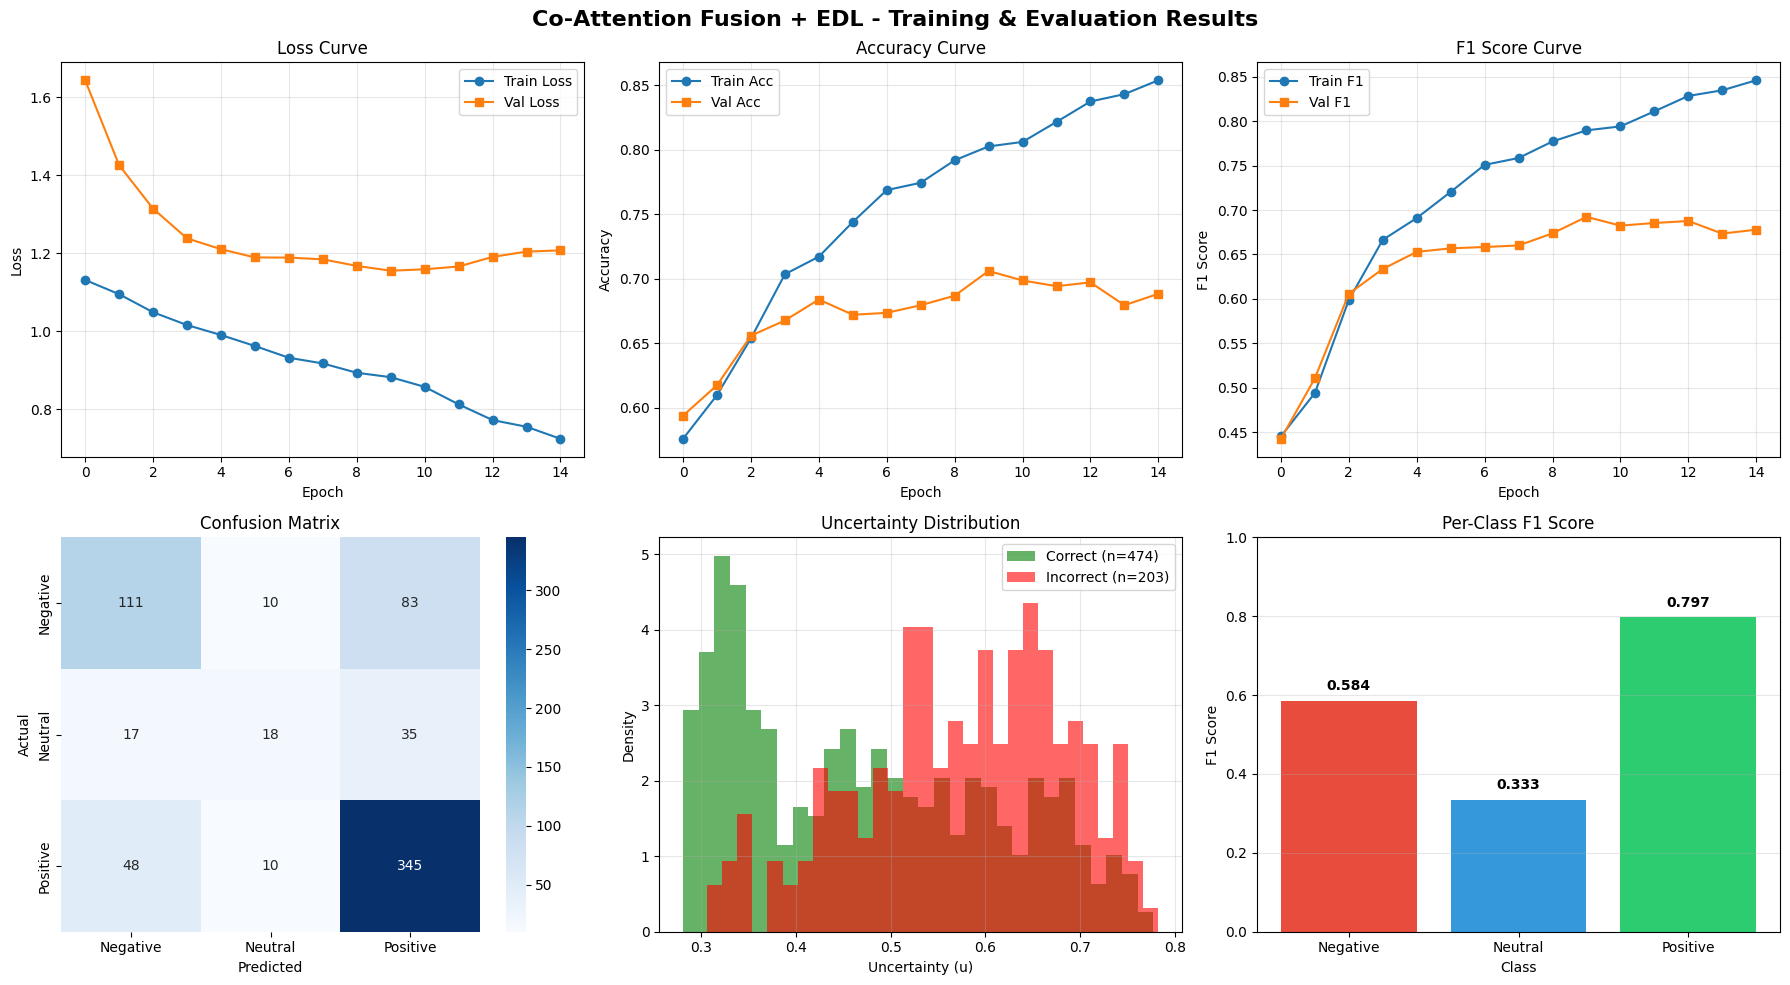

✅ Visualization complete.


In [10]:
# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Co-Attention Fusion + EDL - Training & Evaluation Results", fontsize=16, fontweight="bold")

# 1. Training & Validation Loss
axes[0, 0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0, 0].plot(history["val_loss"], label="Val Loss", marker="s")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curve")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Training & Validation Accuracy
axes[0, 1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[0, 1].plot(history["val_acc"], label="Val Acc", marker="s")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy Curve")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Training & Validation F1
axes[0, 2].plot(history["train_f1"], label="Train F1", marker="o")
axes[0, 2].plot(history["val_f1"], label="Val F1", marker="s")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("F1 Score")
axes[0, 2].set_title("F1 Score Curve")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"],
            ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_title("Confusion Matrix")

# 5. Uncertainty Distribution (Correct vs Incorrect)
correct_mask = all_preds == all_labels
axes[1, 1].hist(all_uncertainties[correct_mask], bins=30, alpha=0.6,
                label=f"Correct (n={correct_mask.sum()})", color="green", density=True)
if (~correct_mask).sum() > 0:
    axes[1, 1].hist(all_uncertainties[~correct_mask], bins=30, alpha=0.6,
                    label=f"Incorrect (n={(~correct_mask).sum()})", color="red", density=True)
axes[1, 1].set_xlabel("Uncertainty (u)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Uncertainty Distribution")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Per-class F1 scores
f1_per_class = f1_score(all_labels, all_preds, average=None)
class_names = ["Negative", "Neutral", "Positive"]
bars = axes[1, 2].bar(class_names, f1_per_class, color=["#e74c3c", "#3498db", "#2ecc71"])
axes[1, 2].set_xlabel("Class")
axes[1, 2].set_ylabel("F1 Score")
axes[1, 2].set_title("Per-Class F1 Score")
axes[1, 2].set_ylim(0, 1)
for bar, val in zip(bars, f1_per_class):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
axes[1, 2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\u2705 Visualization complete.")
